In [16]:
#%pip install pandas numpy seaborn matplotlib statsmodels
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt


# Read csv

In [17]:
# Read csv
df = pd.read_csv('../data/processed/candor_dataset_clean.csv')
#print(df)

# Make a pair dataset by deleting the lines with the same call_id

In [28]:
# Make a pair dataset by deleting the lines with the same call_id
df_pair = df.drop_duplicates(subset=['call_id'])

# Delete second partner to use conversation as dyad
#df_pair = df_pair.reset_index(drop=True)

# Extract necessary parameters:
df_subset = df_pair.filter(
  items=['speech_activity_actor', 'speech_activity_partner', 'how_enjoyable_actor', 'how_enjoyable_partner']
  )

# Add other columns
df_subset['speech_activity_ave'] = (df_subset['speech_activity_actor'] + df_subset['speech_activity_partner'])/2
df_subset['speech_activity_diff'] = df_subset['speech_activity_actor'] - df_subset['speech_activity_partner']
df_subset['speech_activity_abs'] = abs(df_subset['speech_activity_diff'])

df_subset['how_enjoyable_ave'] = (df_subset['how_enjoyable_actor'] + df_subset['how_enjoyable_partner'])/2
df_subset['how_enjoyable_diff'] = df_subset['how_enjoyable_actor'] - df_subset['how_enjoyable_partner']
df_subset['how_enjoyable_abs'] = abs(df_subset['how_enjoyable_diff'])

#print(df_subset)

# Make a 4×4 correlation map

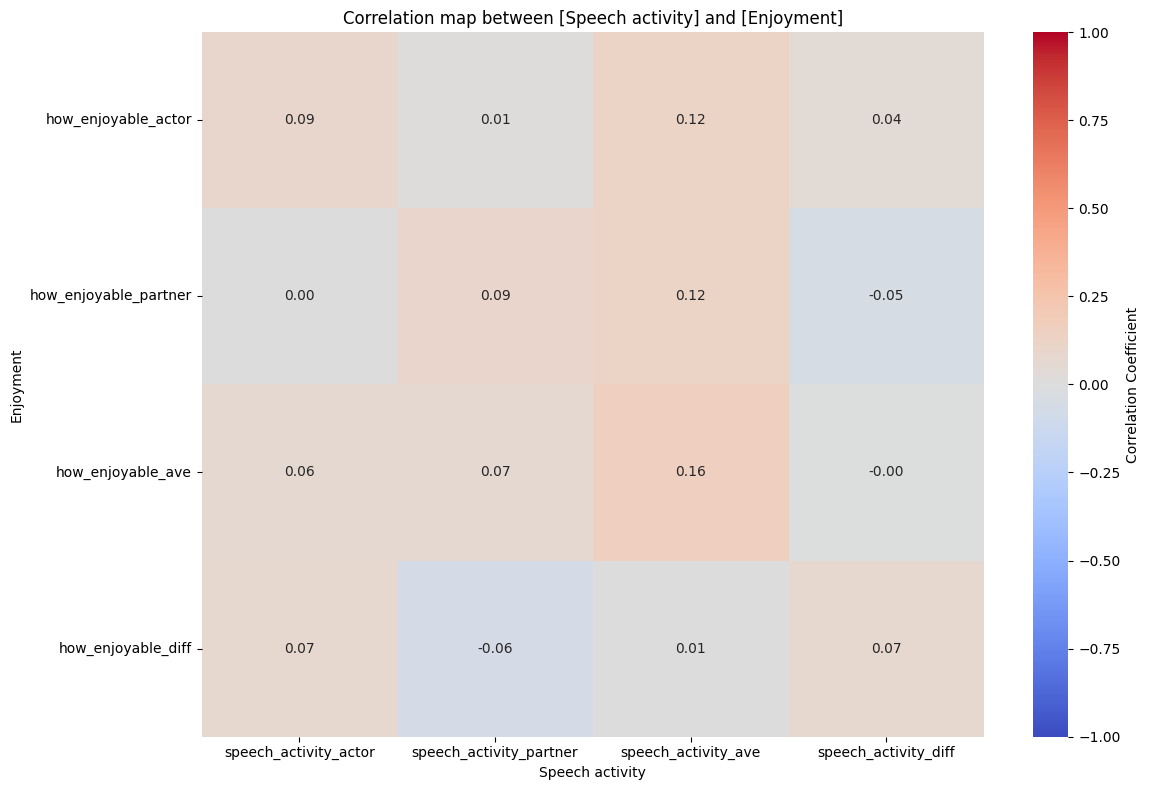

In [29]:
# Make a 4×4 correlation map
src_cols = ['speech_activity_actor', 'speech_activity_partner', 'speech_activity_ave', 'speech_activity_diff']
tar_cols = ['how_enjoyable_actor', 'how_enjoyable_partner', 'how_enjoyable_ave', 'how_enjoyable_diff']
corr_subset = df_subset.corr().loc[tar_cols, src_cols]
#print(corr_subset)

plt.figure(figsize=(12,8))
sns.heatmap(
  corr_subset,
  annot=True,
  cmap='coolwarm',
  fmt=".2f",
  vmin=-1, vmax=1,
  center=0,
  cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Correlation map between [Speech activity] and [Enjoyment]")
plt.xlabel("Speech activity")
plt.ylabel("Enjoyment")

plt.tight_layout()
plt.show()

# Make four regressions
- H3-1 : lower activity abs -> higher enjoyable ave
- H3-2 : lower activity abs -> lower enjoyable abs
- H3-3 : higher activity diff -> higher enjoyable diff
- H3-4 : higher activity ave -> higher enjoyable ave

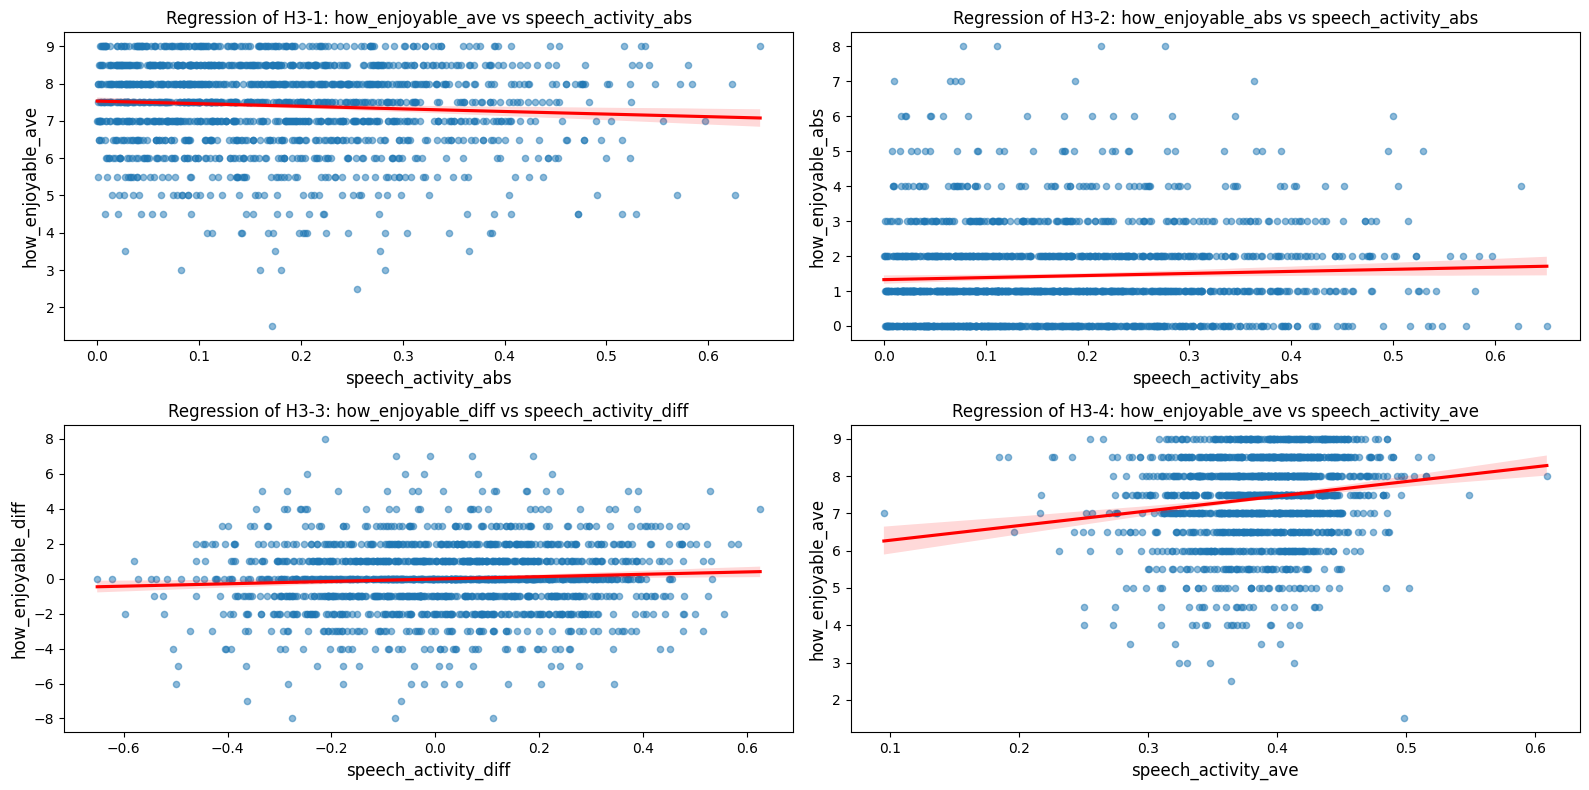

In [30]:
# Make four regressions
# H3-1 : lower activity abs -> higher enjoyable ave
# H3-2 : lower activity abs -> lower enjoyable abs
# H3-3 : higher activity diff -> higher enjoyable diff
# H3-4 : higher activity ave -> higher enjoyable ave

pairs = [('speech_activity_abs', 'how_enjoyable_ave'),
          ('speech_activity_abs', 'how_enjoyable_abs'), 
          ('speech_activity_diff', 'how_enjoyable_diff'), 
          ('speech_activity_ave', 'how_enjoyable_ave')]

fig, axes = plt.subplots(2, 2, figsize=(16,8))
axes = axes.flatten()

for i, (col_x, col_y) in enumerate(pairs):
  sns.regplot(
    data=df_subset,
    x=col_x,
    y=col_y,
    ax=axes[i],
    scatter_kws={'alpha': 0.5, 's': 20},
    line_kws={'color': 'red'},
    ci=95
  )

  axes[i].set_title(f"Regression of H3-{i+1}: {col_y} vs {col_x}")
  axes[i].set_xlabel(col_x, fontsize=12)
  axes[i].set_ylabel(col_y, fontsize=12)

plt.tight_layout()
plt.show()

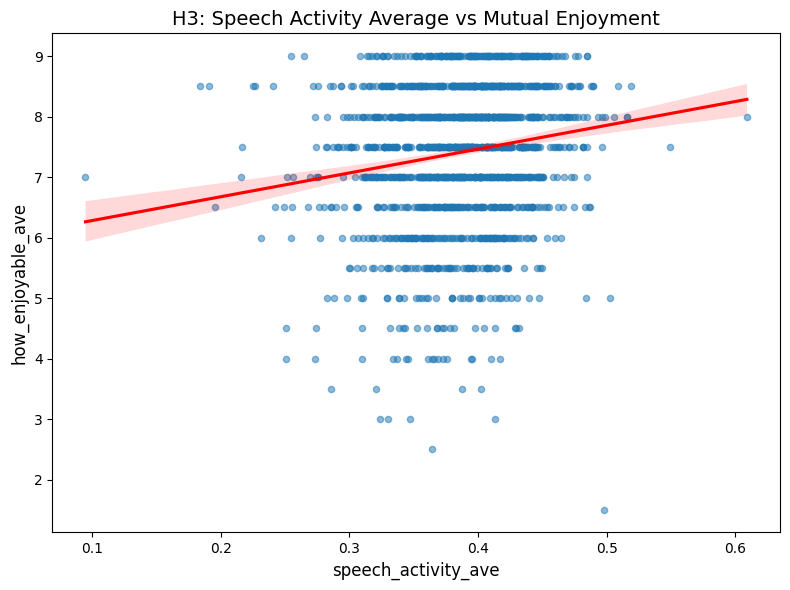

In [34]:
# Make a single regression for H3-4
# H3-4 : higher activity ave -> higher enjoyable ave

col_x = 'speech_activity_ave'
col_y = 'how_enjoyable_ave'

plt.figure(figsize=(8, 6))

sns.regplot(
    data=df_subset,
    x=col_x,
    y=col_y,
    scatter_kws={'alpha': 0.5, 's': 20},
    line_kws={'color': 'red'},
    ci=95
)

plt.title(f"H3: Speech Activity Average vs Mutual Enjoyment", fontsize=14)
plt.xlabel(col_x, fontsize=12)
plt.ylabel(col_y, fontsize=12)

plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
import statsmodels.formula.api as smf

print("\n=== Statistical Summaries (Key Metrics) ===")

results_list = []

for i, (col_x, col_y) in enumerate(pairs):
    formula = f"{col_y} ~ {col_x}"
    model = smf.ols(formula, data=df_subset).fit()
    
    # Extract key statistical features
    coef = model.params[col_x]
    std_err = model.bse[col_x]
    t_val = model.tvalues[col_x]
    p_val = model.pvalues[col_x]
    conf_lower = model.conf_int().loc[col_x, 0]
    conf_upper = model.conf_int().loc[col_x, 1]
    r_squared = model.rsquared
    
    results_list.append({
        'Hypothesis': f"H3-{i+1}",
        'X (Source)': col_x,
        'Y (Target)': col_y,
        'R^2': round(r_squared, 3),
        'Coef (β)': round(coef, 3),
        'Std Err': round(std_err, 3),
        't': round(t_val, 3),
        'p-value': round(p_val, 4),
        '95% CI': f"[{conf_lower:.3f}, {conf_upper:.3f}]"
    })

# Output
summary_df = pd.DataFrame(results_list)
print(summary_df.to_string(index=False))


=== Statistical Summaries (Key Metrics) ===
Hypothesis           X (Source)         Y (Target)   R^2  Coef (β)  Std Err      t  p-value           95% CI
      H3-1  speech_activity_abs  how_enjoyable_ave 0.006    -0.696    0.233 -2.979   0.0029 [-1.154, -0.238]
      H3-2  speech_activity_abs  how_enjoyable_abs 0.003     0.589    0.270  2.179   0.0294   [0.059, 1.119]
      H3-3 speech_activity_diff how_enjoyable_diff 0.005     0.679    0.229  2.968   0.0030   [0.230, 1.127]
      H3-4  speech_activity_ave  how_enjoyable_ave 0.026     3.937    0.608  6.478   0.0000   [2.745, 5.129]
